## Clustering analysis using pyclustering & Kmeans

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import numpy as np
import warnings
np.warnings = warnings
import math

In [3]:
#access to custom functions library folder
import sys

if '/content/drive/MyDrive/datamininglabs/Functions' not in sys.path:
  sys.path.append('/content/drive/MyDrive/datamininglabs/Functions')

In [4]:
import function as fun

## Importing dataset

In [5]:
file_path = '/content/drive/MyDrive/datamininglabs/CE3/'

[['SALES1','SALES2', 'SALES3','NETPROF1','NETPROF2','NETPROF3','ASSETS1', 'ASSETS2', 'SALEPER1'
               ,'EQUITY1', 'EQUITY2', 'EMPLOY1', 'EMPLOY2', 'PROFPER', 'MARKTCAP', 'PROFTAS1', 'PROFTAS2', 'PROFTAS3']]

In [6]:
df = pd.read_excel(file_path + 'Asia Dataset.xlsx')
df_input = df[['SALES1','SALES2', 'SALES3','NETPROF1','NETPROF2','NETPROF3','ASSETS1', 'ASSETS2', 'SALEPER1'
               ,'EQUITY1', 'EQUITY2', 'EMPLOY1', 'EMPLOY2', 'PROFPER', 'MARKTCAP', 'PROFTAS1', 'PROFTAS2', 'PROFTAS3']]
df_input = df_input.copy()
df_input.head(3)

,SALES1,SALES2,SALES3,NETPROF1,NETPROF2,NETPROF3,ASSETS1,ASSETS2,SALEPER1,EQUITY1,EQUITY2,EMPLOY1,EMPLOY2,PROFPER,MARKTCAP,PROFTAS1,PROFTAS2,PROFTAS3
0,155976.9,-1.2,1,92.30,368.8,232.0,42171.2,12.0,3.70,3953.8,79.0,7345.0,280.0,12569.0,8461.5,0.1,0.2,2.3
1,147571.8,-4.9,2,213.20,42.9,109.0,53233.1,9.0,2.77,5587.0,49.0,8341.0,253.0,25564.0,12378.8,0.1,0.4,3.8
2,143131.9,-2.7,3,1.18,1.8,182.0,36316.0,16.0,3.94,6148.5,38.0,6491.0,314.0,18182.0,9695.4,0.1,0.3,1.9


In [7]:
len(df)

1000

In [8]:
df.describe()

,RANK,SALES1,SALES2,SALES3,NETPROF1,NETPROF2,NETPROF3,ASSETS1,ASSETS2,SALEPER1,EQUITY1,EQUITY2,EMPLOY1,EMPLOY2,PROFPER,MARKTCAP,PROFTAS1,PROFTAS2,PROFTAS3
count,1000.000000,1000.000000,988.000000,1000.000000,978.000000,827.000000,961.000000,934.000000,934.000000,934.000000,918.000000,918.000000,988.000000,988.000000,8.920000e+02,690.000000,902.000000,857.000000,841.000000
mean,500.500000,4737.900000,5.836235,500.500000,89.444407,41.331318,481.000000,4997.495996,467.500000,1.553490,1508.978115,459.500000,11466.645749,494.500000,3.237678e+04,3691.205609,3.284812,3.046558,12.628894
std,288.819436,11947.788477,14.806278,288.819436,250.760364,173.817474,277.561104,9336.917444,269.766875,2.478353,2890.148023,265.148072,38017.213024,285.355334,2.674407e+05,7370.387965,6.945384,7.302748,120.190257
min,1.000000,1118.100000,-84.100000,1.000000,-1970.000000,-98.800000,1.000000,2.030000,1.000000,0.010000,-2.500000,1.000000,8.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,250.750000,1502.525000,-1.300000,250.750000,4.525000,-8.250000,241.000000,1267.250000,234.250000,0.710000,244.900000,230.250000,1866.500000,247.750000,3.894000e+03,697.750000,0.400000,0.500000,2.400000
50%,500.500000,2157.200000,2.400000,500.500000,26.700000,5.400000,481.000000,2306.350000,467.500000,1.010000,676.400000,459.500000,3801.500000,494.500000,9.036500e+03,1615.900000,1.250000,1.400000,4.600000
75%,750.250000,3855.175000,8.725000,750.250000,85.275000,34.300000,721.000000,4772.875000,700.750000,1.607500,1567.775000,688.750000,8407.500000,741.250000,1.856400e+04,3625.975000,3.100000,3.200000,8.400000
max,1000.000000,155976.900000,125.900000,1000.000000,2842.700000,2015.800000,961.000000,130901.200000,934.000000,42.090000,41729.400000,918.000000,700000.000000,988.000000,7.095000e+06,130741.400000,68.900000,132.100000,3443.800000


In [9]:
df_input.describe()

,SALES1,SALES2,SALES3,NETPROF1,NETPROF2,NETPROF3,ASSETS1,ASSETS2,SALEPER1,EQUITY1,EQUITY2,EMPLOY1,EMPLOY2,PROFPER,MARKTCAP,PROFTAS1,PROFTAS2,PROFTAS3
count,1000.000000,988.000000,1000.000000,978.000000,827.000000,961.000000,934.000000,934.000000,934.000000,918.000000,918.000000,988.000000,988.000000,8.920000e+02,690.000000,902.000000,857.000000,841.000000
mean,4737.900000,5.836235,500.500000,89.444407,41.331318,481.000000,4997.495996,467.500000,1.553490,1508.978115,459.500000,11466.645749,494.500000,3.237678e+04,3691.205609,3.284812,3.046558,12.628894
std,11947.788477,14.806278,288.819436,250.760364,173.817474,277.561104,9336.917444,269.766875,2.478353,2890.148023,265.148072,38017.213024,285.355334,2.674407e+05,7370.387965,6.945384,7.302748,120.190257
min,1118.100000,-84.100000,1.000000,-1970.000000,-98.800000,1.000000,2.030000,1.000000,0.010000,-2.500000,1.000000,8.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1502.525000,-1.300000,250.750000,4.525000,-8.250000,241.000000,1267.250000,234.250000,0.710000,244.900000,230.250000,1866.500000,247.750000,3.894000e+03,697.750000,0.400000,0.500000,2.400000
50%,2157.200000,2.400000,500.500000,26.700000,5.400000,481.000000,2306.350000,467.500000,1.010000,676.400000,459.500000,3801.500000,494.500000,9.036500e+03,1615.900000,1.250000,1.400000,4.600000
75%,3855.175000,8.725000,750.250000,85.275000,34.300000,721.000000,4772.875000,700.750000,1.607500,1567.775000,688.750000,8407.500000,741.250000,1.856400e+04,3625.975000,3.100000,3.200000,8.400000
max,155976.900000,125.900000,1000.000000,2842.700000,2015.800000,961.000000,130901.200000,934.000000,42.090000,41729.400000,918.000000,700000.000000,988.000000,7.095000e+06,130741.400000,68.900000,132.100000,3443.800000


In [10]:
df_input.dtypes

,0
SALES1,float64
SALES2,float64
SALES3,int64
NETPROF1,float64
NETPROF2,float64
NETPROF3,float64
ASSETS1,float64
ASSETS2,float64
SALEPER1,float64
EQUITY1,float64


## Understanding missing values and Inputation techniques

In [11]:
fun.metadata(df_input)

,column_name,datatype,missing_percent,unique,mean,std,min,25%,50%,75%,max
0,SALES1,float64,0.0,985,4737.900000,11947.788477,1118.10,1502.525,2157.20,3855.1750,155976.90
1,SALES2,float64,1.2,352,5.836235,14.806278,-84.10,-1.300,2.40,8.7250,125.90
2,SALES3,int64,0.0,1000,500.500000,288.819436,1.00,250.750,500.50,750.2500,1000.00
3,NETPROF1,float64,2.2,728,89.444407,250.760364,-1970.00,4.525,26.70,85.2750,2842.70
4,NETPROF2,float64,17.3,595,41.331318,173.817474,-98.80,-8.250,5.40,34.3000,2015.80
5,NETPROF3,float64,3.9,961,481.000000,277.561104,1.00,241.000,481.00,721.0000,961.00
6,ASSETS1,float64,6.6,928,4997.495996,9336.917444,2.03,1267.250,2306.35,4772.8750,130901.20
7,ASSETS2,float64,6.6,934,467.500000,269.766875,1.00,234.250,467.50,700.7500,934.00
8,SALEPER1,float64,6.6,306,1.553490,2.478353,0.01,0.710,1.01,1.6075,42.09
9,EQUITY1,float64,8.2,904,1508.978115,2890.148023,-2.50,244.900,676.40,1567.7750,41729.40


<Axes: >

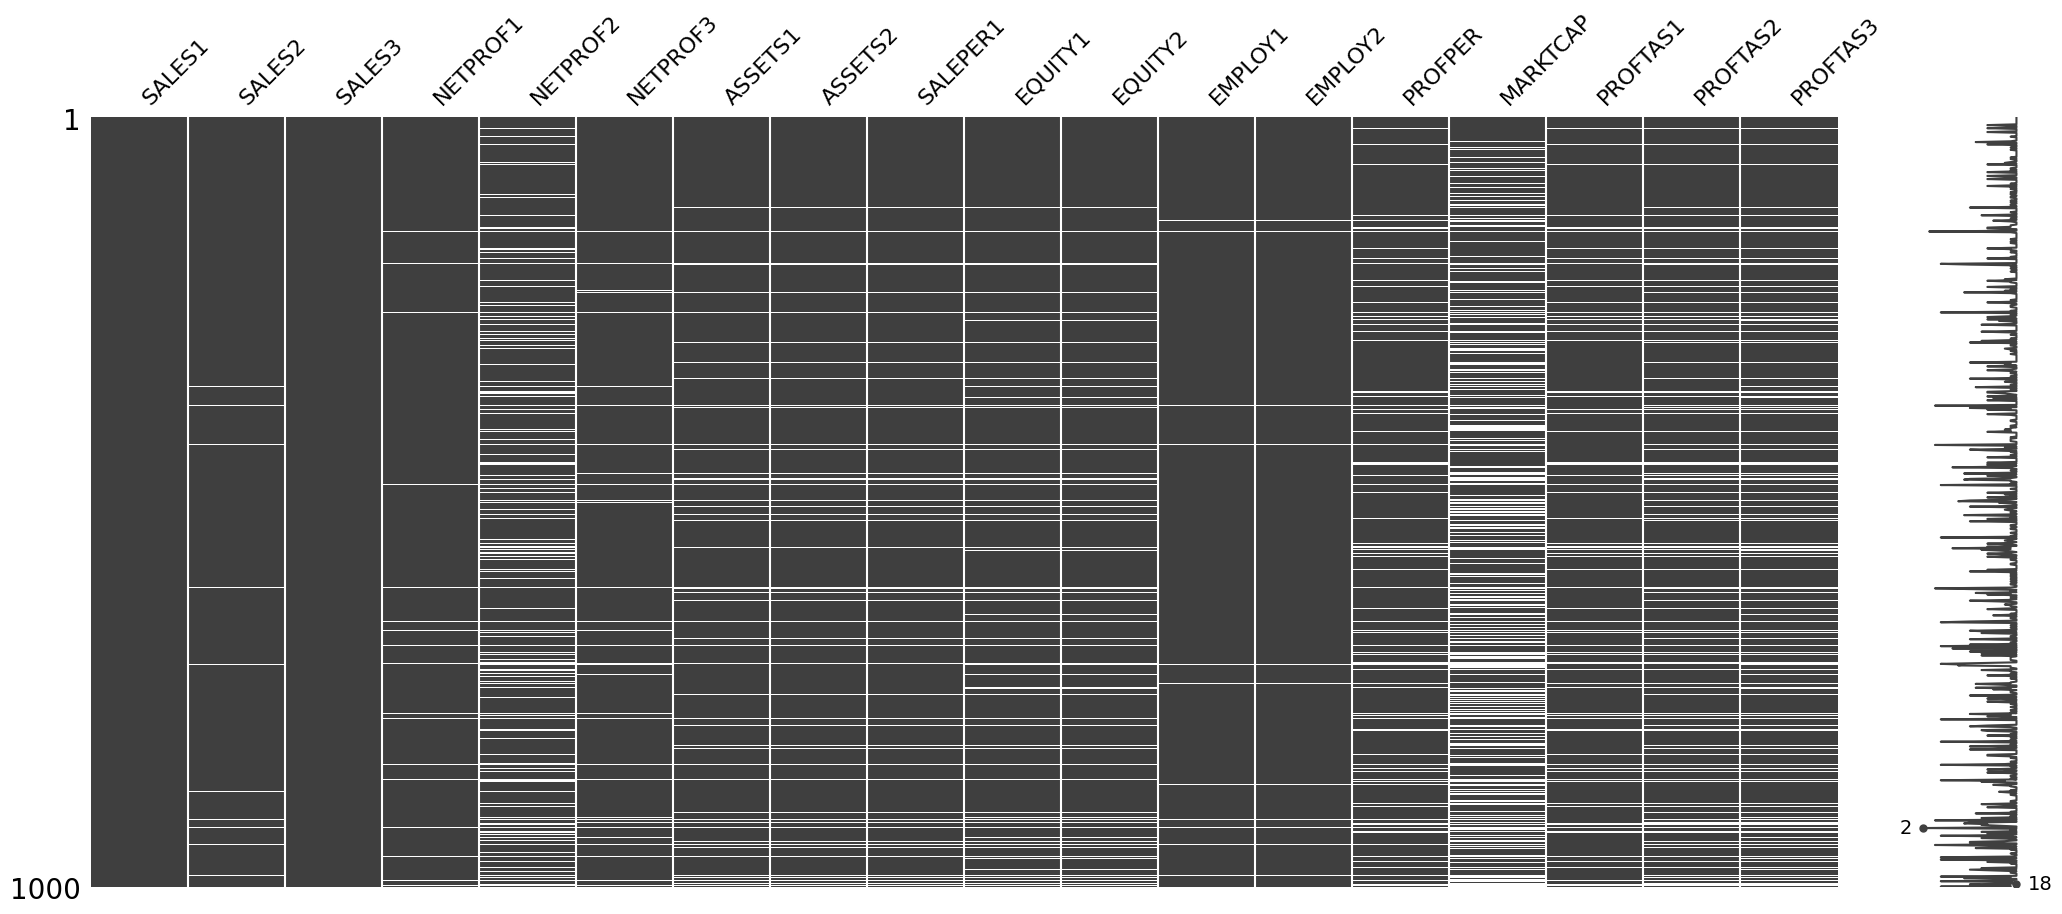

In [12]:
# using missingno library to visualize missing data point distribution,
# This helps us decide, what approach to use for missing values.
import missingno as msno

msno.matrix(df_input)

<Axes: >

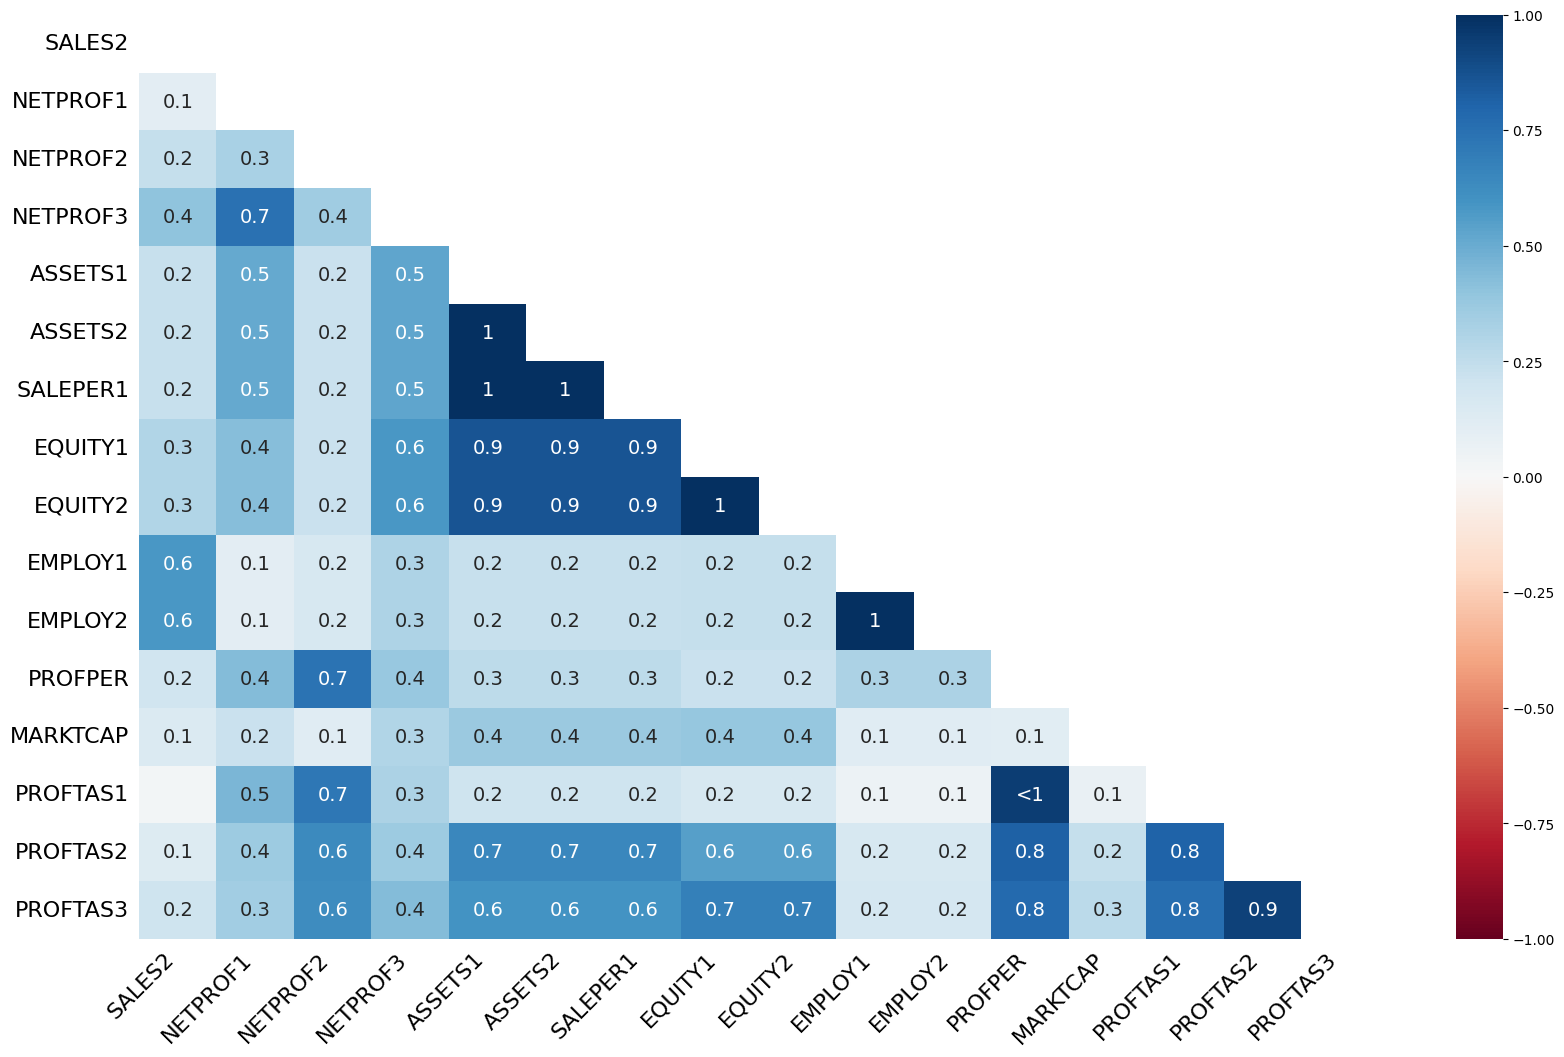

In [13]:
#Heatmap to show corelation of missingness between different columns
msno.heatmap(df_input)

In [14]:
! pip install pyampute

In [15]:
from pyampute.exploration.mcar_statistical_tests import MCARTest
mt = MCARTest(method='little')
print(mt.little_mcar_test(df_input))

0.0


## Using Tree-Based model - **MISSFOREST**: data imputation algorithm

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import mean_squared_error

In [17]:
#checking sklearn version. if version greater than 1.1.3, errors would be faced with using missForest
# import sklearn
# print(sklearn.__version__)

In [18]:
# !pip install scikit-learn==1.6.1

In [19]:
# !pip install missingpy

In [20]:
#missforrest requires sklearn releases on specific module

# import sklearn.neighbors._base
# sys.module['sklearn.neighbors.base'] = sklearn.neighbors._base

# from missingpy import MissForest

##RandomForest Regressor (RFR) as an iterative imputer,

Using a columnto tune the randomforest regressor

In [21]:
#Defining the estimator
rf_regressor = RandomForestRegressor(random_state=101)
#define the iterative imputer with the RFR as it's estimator
iterative_imputer = IterativeImputer(estimator=rf_regressor, max_iter=20, tol=0.1, random_state=101)

In [22]:
#define the parameter grid for RFR
param_grid = {
    'n_estimators': randint(50,500), # No of trees in the forest
    'max_depth': randint(3, 10), # Max dept of the tree
    'min_samples_split': [20,30,40,50,60], #This can not be too small, determined based on sample size
    'max_samples': [0.5,0.75,1.0] # No of sampes to draw from X to train each nbase estimator
}

In [23]:
#Setting up RandomizeSearchCV to tune the hyperparameters
random_search = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=param_grid,
    n_iter = 30, # No of parameters that are sampled
    scoring='neg_mean_squared_error',
    cv=5, # no of folds in cross-validation
    random_state=42,
    n_jobs=-1 # to run in parallel using available cores
)

In [24]:
df_input = df_input.drop('MARKTCAP', axis=1) # missing percent above 30%, not good for modeling

In [25]:
#drop rows with any missing values
df_input_filtered = df_input.dropna()

#splitting into features and target
X=df_input_filtered.drop(columns=['NETPROF2'])
y = df_input_filtered['NETPROF2']

In [26]:
%%time
random_search.fit(X,y)

print('All results:')

for mean_score, params in zip(random_search.cv_results_['mean_test_score'],
                              random_search.cv_results_['params']):
   params_str = '\n'.join([f"{key}: {value}" for key,value in params.items()])
   print(f"Score: {mean_score}, Parameters:\n{params_str}\n")

best_params = random_search.best_params_
best_score = random_search.best_score_

best_params_str = '\n'.join([f"{key}: {value}" for key,value in best_params.items()])
print("\n Bestparameters:\n" + best_params_str)
print(f"Best score: (neg_mean_squared_error):{best_score}")
print()
# print("Best parameters:", best_params)
# print("Best score(neg_mean_squared_error):", best_score)

All results:
Score: -25981.430732310248, Parameters:
max_depth: 9
max_samples: 0.5
min_samples_split: 40
n_estimators: 121

Score: -26187.36393170723, Parameters:
max_depth: 7
max_samples: 0.5
min_samples_split: 30
n_estimators: 264

Score: -25790.478834793677, Parameters:
max_depth: 5
max_samples: 1.0
min_samples_split: 60
n_estimators: 149

Score: -25827.89353090445, Parameters:
max_depth: 5
max_samples: 0.75
min_samples_split: 60
n_estimators: 307

Score: -26159.854675914383, Parameters:
max_depth: 6
max_samples: 0.75
min_samples_split: 30
n_estimators: 241

Score: -26412.996151543164, Parameters:
max_depth: 6
max_samples: 0.5
min_samples_split: 20
n_estimators: 363

Score: -26056.860033265653, Parameters:
max_depth: 8
max_samples: 0.5
min_samples_split: 50
n_estimators: 394

Score: -25675.142286545874, Parameters:
max_depth: 3
max_samples: 1.0
min_samples_split: 40
n_estimators: 219

Score: -25965.56054558194, Parameters:
max_depth: 6
max_samples: 1.0
min_samples_split: 40
n_estima

In [27]:
#directly applying the best parameters to RFR, as below:
%%time
imputer = IterativeImputer(estimator=RandomForestRegressor(**best_params,
                                                           n_jobs=-1, random_state=101), max_iter=20, tol=0.1, random_state=101)
imputed_data = imputer.fit_transform(df_input) #imputing mising values
imputed_df = pd.DataFrame(imputed_data, columns=df_input.columns) #Create imputed dataframe

CPU times: user 57.6 s, sys: 1.09 s, total: 58.7 s
Wall time: 38.9 s


In [28]:
imputed_df.head(3)

,SALES1,SALES2,SALES3,NETPROF1,NETPROF2,NETPROF3,ASSETS1,ASSETS2,SALEPER1,EQUITY1,EQUITY2,EMPLOY1,EMPLOY2,PROFPER,PROFTAS1,PROFTAS2,PROFTAS3
0,155976.9,-1.2,1.0,92.30,368.8,232.0,42171.2,12.0,3.70,3953.8,79.0,7345.0,280.0,12569.0,0.1,0.2,2.3
1,147571.8,-4.9,2.0,213.20,42.9,109.0,53233.1,9.0,2.77,5587.0,49.0,8341.0,253.0,25564.0,0.1,0.4,3.8
2,143131.9,-2.7,3.0,1.18,1.8,182.0,36316.0,16.0,3.94,6148.5,38.0,6491.0,314.0,18182.0,0.1,0.3,1.9


In [29]:
# list of columns in IMputed-df to be added to dfz_input with a prefix
columns_to_add = ['SALES2','NETPROF1','NETPROF2','NETPROF3','ASSETS1', 'ASSETS2', 'SALEPER1'
               ,'EQUITY1', 'EQUITY2', 'EMPLOY1', 'EMPLOY2', 'PROFPER', 'PROFTAS1', 'PROFTAS2', 'PROFTAS3']
#iterate over each column and add them to df_input with a new column name prefix
for column in columns_to_add:
  df_input[f'Tree_Imputed_{column}'] = imputed_df[column]

In [30]:
df_input.head(3)

,SALES1,SALES2,SALES3,NETPROF1,NETPROF2,NETPROF3,ASSETS1,ASSETS2,SALEPER1,EQUITY1,EQUITY2,EMPLOY1,EMPLOY2,PROFPER,PROFTAS1,PROFTAS2,PROFTAS3,Tree_Imputed_SALES2,Tree_Imputed_NETPROF1,Tree_Imputed_NETPROF2,Tree_Imputed_NETPROF3,Tree_Imputed_ASSETS1,Tree_Imputed_ASSETS2,Tree_Imputed_SALEPER1,Tree_Imputed_EQUITY1,Tree_Imputed_EQUITY2,Tree_Imputed_EMPLOY1,Tree_Imputed_EMPLOY2,Tree_Imputed_PROFPER,Tree_Imputed_PROFTAS1,Tree_Imputed_PROFTAS2,Tree_Imputed_PROFTAS3
0,155976.9,-1.2,1,92.30,368.8,232.0,42171.2,12.0,3.70,3953.8,79.0,7345.0,280.0,12569.0,0.1,0.2,2.3,-1.2,92.30,368.8,232.0,42171.2,12.0,3.70,3953.8,79.0,7345.0,280.0,12569.0,0.1,0.2,2.3
1,147571.8,-4.9,2,213.20,42.9,109.0,53233.1,9.0,2.77,5587.0,49.0,8341.0,253.0,25564.0,0.1,0.4,3.8,-4.9,213.20,42.9,109.0,53233.1,9.0,2.77,5587.0,49.0,8341.0,253.0,25564.0,0.1,0.4,3.8
2,143131.9,-2.7,3,1.18,1.8,182.0,36316.0,16.0,3.94,6148.5,38.0,6491.0,314.0,18182.0,0.1,0.3,1.9,-2.7,1.18,1.8,182.0,36316.0,16.0,3.94,6148.5,38.0,6491.0,314.0,18182.0,0.1,0.3,1.9


In [31]:
df_input.columns

Index(['SALES1', 'SALES2', 'SALES3', 'NETPROF1', 'NETPROF2', 'NETPROF3',
       'ASSETS1', 'ASSETS2', 'SALEPER1', 'EQUITY1', 'EQUITY2', 'EMPLOY1',
       'EMPLOY2', 'PROFPER', 'PROFTAS1', 'PROFTAS2', 'PROFTAS3',
       'Tree_Imputed_SALES2', 'Tree_Imputed_NETPROF1', 'Tree_Imputed_NETPROF2',
       'Tree_Imputed_NETPROF3', 'Tree_Imputed_ASSETS1', 'Tree_Imputed_ASSETS2',
       'Tree_Imputed_SALEPER1', 'Tree_Imputed_EQUITY1', 'Tree_Imputed_EQUITY2',
       'Tree_Imputed_EMPLOY1', 'Tree_Imputed_EMPLOY2', 'Tree_Imputed_PROFPER',
       'Tree_Imputed_PROFTAS1', 'Tree_Imputed_PROFTAS2',
       'Tree_Imputed_PROFTAS3'],
      dtype='object')

In [32]:
Tree_impute_df = df_input[['SALES1','Tree_Imputed_SALES2', 'SALES3','Tree_Imputed_NETPROF1', 'Tree_Imputed_NETPROF2',
       'Tree_Imputed_NETPROF3', 'Tree_Imputed_ASSETS1', 'Tree_Imputed_ASSETS2',
       'Tree_Imputed_SALEPER1', 'Tree_Imputed_EQUITY1', 'Tree_Imputed_EQUITY2',
       'Tree_Imputed_EMPLOY1', 'Tree_Imputed_EMPLOY2', 'Tree_Imputed_PROFPER',
       'Tree_Imputed_PROFTAS1','Tree_Imputed_PROFTAS2', 'Tree_Imputed_PROFTAS3']]

In [33]:
fun.metadata(Tree_impute_df) #new df

,column_name,datatype,missing_percent,unique,mean,std,min,25%,50%,75%,max
0,SALES1,float64,0.0,985,4737.900000,11947.788477,1118.10,1502.525,2157.200000,3855.175000,155976.90
1,Tree_Imputed_SALES2,float64,0.0,364,5.903970,14.756148,-84.10,-1.200,2.500000,8.800000,125.90
2,SALES3,int64,0.0,1000,500.500000,288.819436,1.00,250.750,500.500000,750.250000,1000.00
3,Tree_Imputed_NETPROF1,float64,0.0,729,87.999868,248.171019,-1970.00,5.050,25.000000,83.825000,2842.70
4,Tree_Imputed_NETPROF2,float64,0.0,736,41.412289,158.950392,-98.80,-3.500,12.550000,35.011102,2015.80
5,Tree_Imputed_NETPROF3,float64,0.0,972,476.625827,276.044023,1.00,238.750,485.500000,711.250000,961.00
6,Tree_Imputed_ASSETS1,float64,0.0,929,4766.681520,9064.943422,2.03,1312.100,2105.700000,4483.375000,130901.20
7,Tree_Imputed_ASSETS2,float64,0.0,935,478.997748,264.270584,1.00,250.750,500.500000,684.250000,934.00
8,Tree_Imputed_SALEPER1,float64,0.0,317,1.534717,2.396137,0.01,0.730,1.080000,1.560000,42.09
9,Tree_Imputed_EQUITY1,float64,0.0,905,1416.682263,2786.178204,-2.50,277.175,585.200000,1442.600000,41729.40


<Axes: >

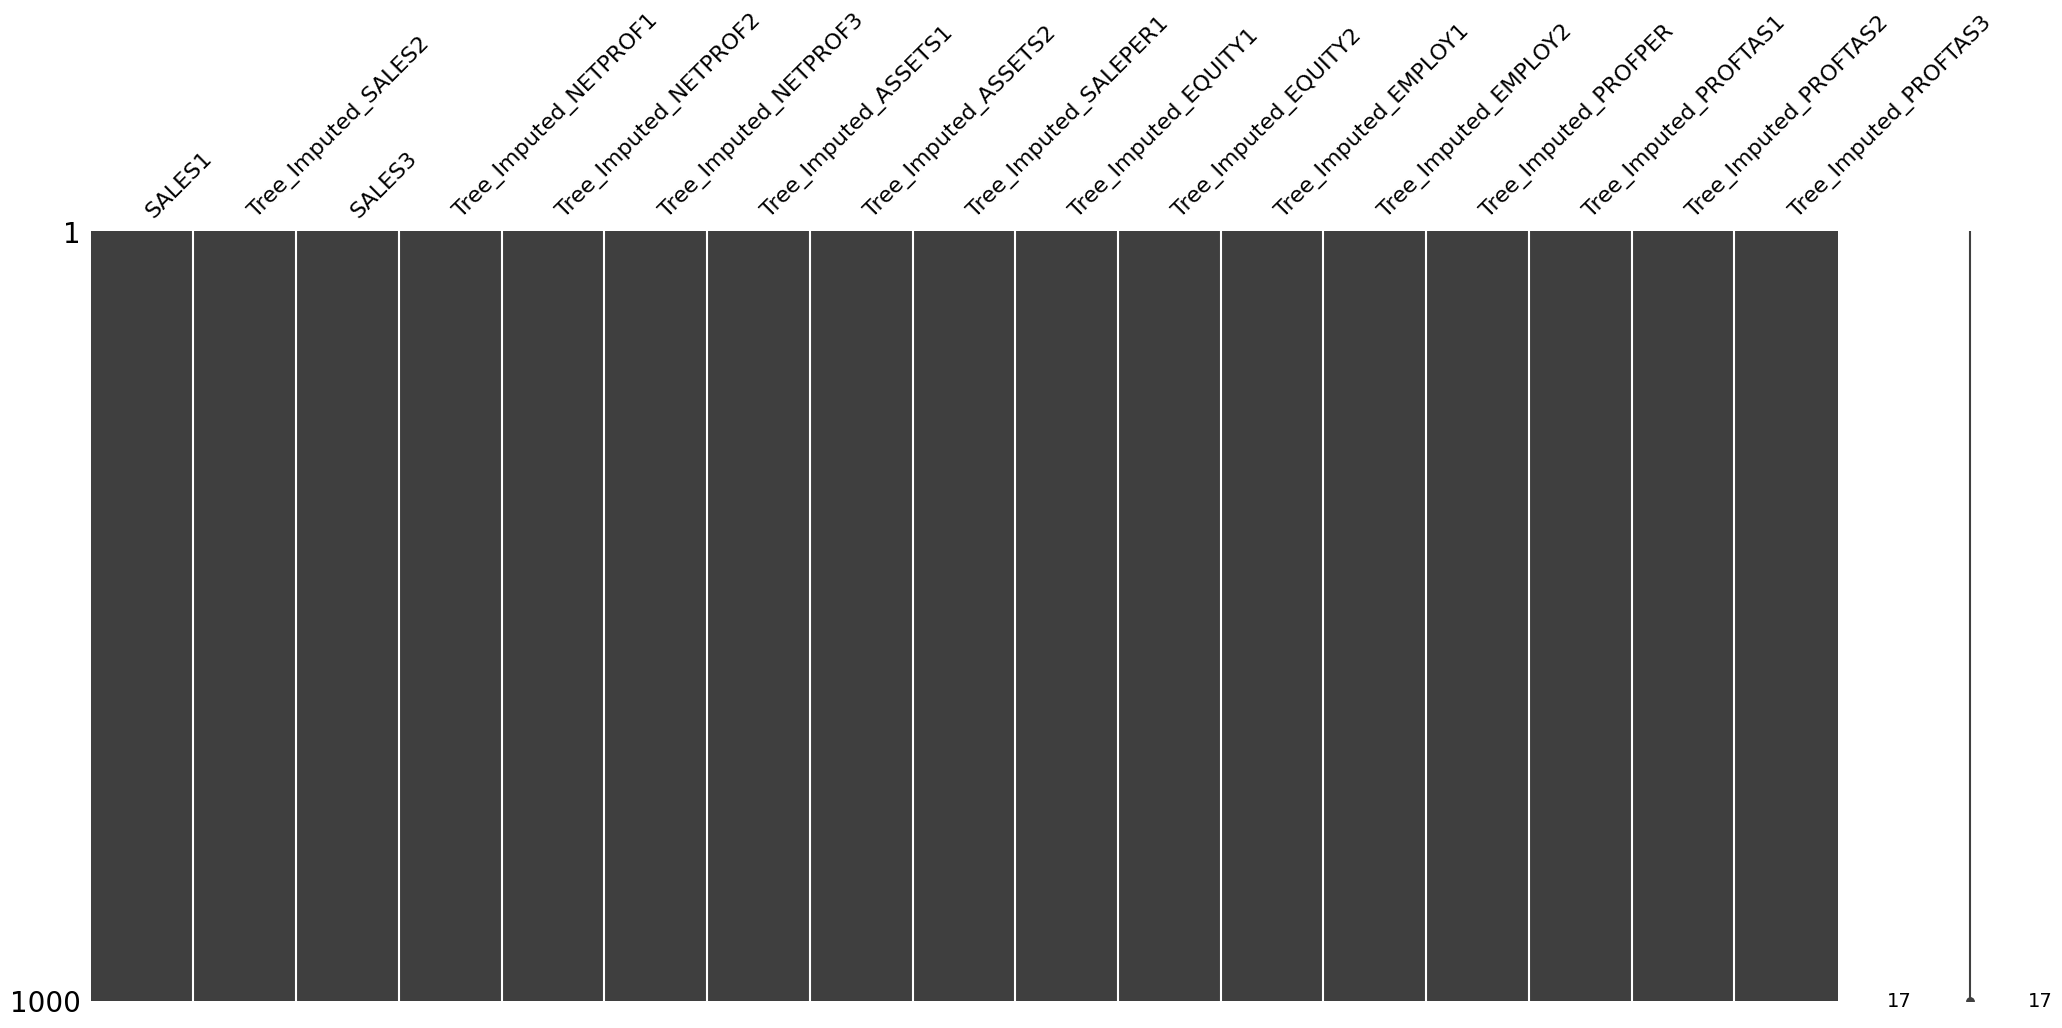

In [34]:
import missingno as msno

msno.matrix(Tree_impute_df)

#Variable normalization

The process of transforming numerical variable to use the same scale is known as normalization or feature scaling<br> For Tree based imputation I shall utilize z-score using StandardScalar

In [35]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
tree_std_features = scaler.fit_transform(Tree_impute_df)
tree_std_features[:5]

array([[ 1.26646598e+01, -4.81665325e-01, -1.73031962e+00,
         1.73359616e-02,  2.06071545e+00, -8.86627534e-01,
         4.12834731e+00, -1.76800390e+00,  9.04107805e-01,
         9.11064211e-01, -1.52780001e+00, -1.06663904e-01,
        -7.56677883e-01, -7.97285080e-02, -4.43158412e-01,
        -3.97818333e-01, -9.53963010e-02],
       [ 1.19608219e+01, -7.32533733e-01, -1.72685552e+00,
         5.04743782e-01,  9.36427634e-03, -1.33243159e+00,
         5.34925235e+00, -1.77936158e+00,  5.15788910e-01,
         1.49753682e+00, -1.64409355e+00, -8.02997194e-02,
        -8.51917831e-01, -3.04869594e-02, -4.43158412e-01,
        -3.69199841e-01, -8.43621560e-02],
       [ 1.15890275e+01, -5.83368733e-01, -1.72339142e+00,
        -3.50013919e-01, -2.49336347e-01, -1.06784870e+00,
         3.48210722e+00, -1.75286032e+00,  1.00431913e+00,
         1.69916821e+00, -1.68673451e+00, -1.29269339e-01,
        -6.36746097e-01, -5.84593420e-02, -4.43158412e-01,
        -3.83509087e-01, -9.8

In [36]:
# from sklearn.preprocessing import MinMaxScaler

# range_scaler = MinMaxScaler()
# Tree_range_features = range_scaler.fit_transform(Tree_impute_df)
# Tree_range_features[:5]

#Using pyclustering Library in addition to KMeans from Sklearn

In [37]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=17659843ca72d2ef0075af6070b51c637ba4a0665eabbe441f30d182c1ec9a66
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [38]:
#import sklearn KMeans
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier #for variable importance

#pyclustering Kmeans
from pyclustering.cluster.kmeans import kmeans
from pyclustering.utils.metric import distance_metric

from pyclustering.cluster.center_initializer import random_center_initializer
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer

from pyclustering.cluster.encoder import type_encoding
from pyclustering.cluster.encoder import cluster_encoder

#evaluation
from sklearn.metrics.pairwise import pairwise_distances_argmin

#data visualization
import matplotlib.pyplot as plt
%matplotlib inline

from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings("ignore")

#Clustering

Kmeans in sklearn does not have an option to change distance metric and, by default, uses euclidean distance.

It uses 2 algorithms :
- lloyd: Default, a classical k-means clustering algorithm
- elkan: uses triangle inequality to make the algorithm more efficient, but can be memory intensive

#Determining number of clusters

The optimal number of clusters(k) can be determined using the elbow method.
we will use KelbowVisualizer from 'Yellowbrick cluster module to visualize the cluster'

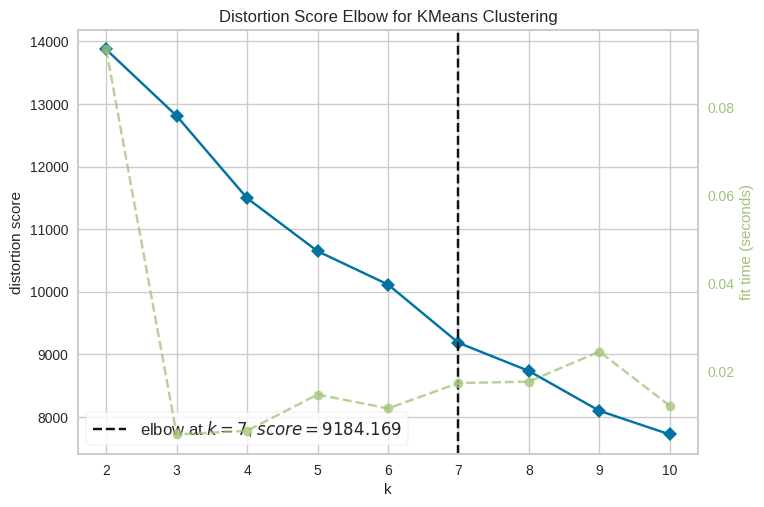

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
visualizer= KElbowVisualizer(KMeans(random_state=80), k=(2, 11))

visualizer.fit(tree_std_features) #fit the data to the visualizer
visualizer.show() # Finalize and render the figure

In [40]:
# model = KMeans(random_state=80)
# visualizer= KElbowVisualizer(model, k=(2, 11))

# visualizer.fit(Tree_range_features)
# visualizer.show()

LKER_K KMEANS++ clusters lloyd

In [41]:
#no of clusters is based on the elbow method above
# K-means++ is usedto set initial cluster centers
K_means_7_tree = KMeans(init='k-means++', n_clusters=7, n_init=10, max_iter=300, random_state=101)

K_means_7_tree.fit(tree_std_features)

KMeans(n_clusters=7, n_init=10, random_state=101)

In [42]:
from sklearn.metrics.pairwise import pairwise_distances_argmin
# coordinates of cluster center
K_means_7_tree_centroids = K_means_7_tree.cluster_centers_
# assign a cluster label to each data point
K_means_7_tree_labels= pairwise_distances_argmin(tree_std_features, K_means_7_tree_centroids)
#print (k_means_cluster_centers)
print(K_means_7_tree_labels[:10])

[2 2 2 2 2 2 2 0 2 0]


In [43]:
#we can see an outlier cluster below
unique, counts= np.unique(K_means_7_tree_labels, return_counts=True)
print(unique, counts)

[0 1 2 3 4 5 6] [394 552  37   1   7   7   2]


##K-means_5_tree 5 clusters with elkan algorithm

In [44]:
K_means_5_tree = KMeans(init='k-means++', n_clusters=5, n_init=10, max_iter=300, random_state=101, algorithm= 'elkan')
K_means_5_tree.fit(tree_std_features)

KMeans(algorithm='elkan', n_clusters=5, n_init=10, random_state=101)

In [45]:
K_means_5_centroids = K_means_5_tree.cluster_centers_
K_means_5_labels= pairwise_distances_argmin(tree_std_features, K_means_5_centroids)
print(K_means_5_centroids[:10])

[[-2.27293778e-01 -7.83219240e-03  5.44907320e-01 -3.12262796e-01
  -1.37066871e-02  5.48299933e-01 -3.62979056e-01  6.94410993e-01
   1.82042370e-01 -3.77637165e-01  6.94909944e-01 -2.16813002e-01
   5.92200683e-01 -6.18646792e-02 -2.68777987e-01 -1.13411577e-01
  -5.64988712e-02]
 [ 6.92295139e-02 -1.75275451e-01 -7.05510997e-01 -1.84848423e-02
  -1.07322725e-01 -4.37277288e-01  1.69995812e-01 -8.08359794e-01
  -2.36019523e-01  1.94946184e-01 -8.04771434e-01  6.29063125e-02
  -6.23173038e-01 -6.94876397e-02 -1.21591790e-01 -1.37793137e-01
  -7.08986011e-02]
 [ 3.46401780e+00 -2.22105147e-01 -1.60615317e+00  1.53859690e+00
   5.61426539e-02 -1.24342149e+00  4.12233765e+00 -1.72422950e+00
  -1.60898518e-01  3.38233149e+00 -1.62632838e+00  1.78494564e+00
  -1.39480758e+00 -6.97320563e-02 -3.43584870e-02 -2.31846912e-01
  -7.36879610e-02]
 [-1.72909853e-01  1.09772008e+00  1.21441566e-01  1.72777458e+00
   5.97314266e-01 -1.44760004e+00  5.41004216e-02 -4.59346605e-01
  -2.87620324e-01  

In [46]:
unique, counts= np.unique(K_means_5_labels, return_counts=True)
print(unique, counts)

[0 1 2 3 4] [538 355  32  70   5]


EKEZ_2 Kmeans++ 2 clusters elkan

In [47]:
# EKEZ_2 = KMeans(init='k-means++', n_clusters=2, n_init=10, algorithm='elkan', max_iter=300, random_state=101)

# EKEZ_2.fit(tree_std_features)

In [48]:
# EKEZ_2_centroids = EKEZ_2.cluster_centers_
# EKEZ_2_labels= pairwise_distances_argmin(tree_std_features, EKEZ_2_centroids)
# print(EKEZ_2_labels[:10])

In [49]:
# unique, counts= np.unique(EKEZ_2_labels, return_counts=True)
# print(unique, counts)

ERER_4 random 4 clusters elkan

In [50]:
# ERER_4 = KMeans(init='random', n_clusters=4, n_init=10, algorithm='elkan', max_iter=300, random_state=101)

# ERER_4.fit(Tree_range_features)

In [51]:
# ERER_4_centroids = ERER_4.cluster_centers_
# ERER_4_labels= pairwise_distances_argmin(Tree_range_features, ERER_4_centroids)
# print(ERER_4_labels[:10])

In [52]:
# unique, counts= np.unique(ERER_4_labels, return_counts=True)
# print(unique, counts)

# Pyclustering KMeans
I would be considering testing, two distance metrics:
- Manhattan
- Chi-Squared

Elbow method

we use two different initializers

In [53]:
# import elbow method
from pyclustering.cluster.elbow import elbow

In [54]:
# the optimal number of clusters using kmeans++ initializer
kmin, kmax= 2, 11
elbow_instance= elbow(tree_std_features, kmin, kmax, random_state=101, initializer=kmeans_plusplus_initializer)
elbow_instance.process()
amount_clusters= elbow_instance.get_amount()

print(amount_clusters)

7


In [55]:
# the optimal number of clusters using random center initializer
kmin, kmax= 2, 11
elbow_instance= elbow(tree_std_features, kmin, kmax, random_state=101, initializer=random_center_initializer)
elbow_instance.process()
amount_clusters= elbow_instance.get_amount()

print(amount_clusters)

7


In [56]:
# kmin, kmax= 2, 11
# elbow_instance= elbow(Tree_range_features, kmin, kmax, random_state=108, initializer=random_center_initializer)
# elbow_instance.process()
# amount_clusters= elbow_instance.get_amount()

# print(amount_clusters)

##Tree 7 K++ Manhattan

In [57]:
#initialize initial centers using K-means++ method
initial_centers = kmeans_plusplus_initializer(tree_std_features, 7, random_state=101).initialize()

#Create an instance of using manhattan distance measure, which is 2
K_Means_7_Manhattan = kmeans(tree_std_features, initial_centers=initial_centers, random_state=101, metric=distance_metric(2), init='random',)

In [58]:
# run cluster analysis and obtain results
K_Means_7_Manhattan.process()

#this is a list
K_Means_7_Manhattan_clusters= K_Means_7_Manhattan.get_clusters()

K_Means_7_Manhattan_final_centers= K_Means_7_Manhattan.get_centers()

In [59]:
# enumerate encoding type to index labeling to get labels
K_Means_7_Manhattan_Encoding= K_Means_7_Manhattan.get_cluster_encoding()
K_Means_7_Manhattan_Encoder= cluster_encoder(K_Means_7_Manhattan_Encoding, K_Means_7_Manhattan_clusters, tree_std_features)

#get cluster labels
K_Means_7_Manhattan_labels = K_Means_7_Manhattan_Encoder.set_encoding(0).get_clusters()

K_Means_7_Manhattan_labels[:5]

[3, 3, 3, 3, 3]

In [60]:
#we can see an outlier cluster below
unique, counts= np.unique(K_Means_7_Manhattan_labels, return_counts=True)
print(unique, counts)

[0 1 2 3 4 5 6] [349   1   2  38  37 570   3]


## K_Means_5_Chisqr KMeans++ clusters

In [61]:
# initialize initial centers using random method
initial_centers = random_center_initializer(tree_std_features, 5, random_state=101).initialize()

#use Chi-square distance measure, which is 6
K_Means_5_Chisqr = kmeans(tree_std_features, initial_centers=initial_centers, random_state=101, metric=distance_metric(6))

In [62]:
# run cluster analysis and obtain results
K_Means_5_Chisqr.process()
K_Means_5_Chisqr_clusters= K_Means_5_Chisqr.get_clusters()
K_Means_5_Chisqr_centers= K_Means_5_Chisqr.get_centers()

In [63]:
#enumerate encoding types to index labeling to get labels
K_Means_5_Chisqr_Encoding= K_Means_5_Chisqr.get_cluster_encoding()
K_Means_5_Chisqr_Encoder= cluster_encoder(K_Means_5_Chisqr_Encoding, K_Means_5_Chisqr_clusters, tree_std_features)

# get cluster labels
K_Means_5_Chisqr_labels = K_Means_5_Chisqr_Encoder.set_encoding(0).get_clusters()

K_Means_5_Chisqr_labels[:5]

[2, 2, 2, 2, 2]

In [64]:
#we can see the cluster distribution
unique, counts= np.unique(K_Means_5_Chisqr_labels, return_counts=True)
print(unique, counts)

[0 1 2 3 4] [ 48   9  86 525 332]


In [65]:
K_Means_5_Chisqr_label_df = Tree_impute_df.copy()
#creating a dataframe that adds labels to the original data
K_Means_5_Chisqr_label_df['label']= K_Means_5_Chisqr_labels

print(K_Means_5_Chisqr_label_df.head())

     SALES1  Tree_Imputed_SALES2  SALES3  Tree_Imputed_NETPROF1  \
0  155976.9                 -1.2       1                  92.30   
1  147571.8                 -4.9       2                 213.20   
2  143131.9                 -2.7       3                   1.18   
3  140606.1                 -5.2       4                  75.60   
4  135136.9                 -2.2       5                 156.30   

   Tree_Imputed_NETPROF2  Tree_Imputed_NETPROF3  Tree_Imputed_ASSETS1  \
0                  368.8                  232.0               42171.2   
1                   42.9                  109.0               53233.1   
2                    1.8                  182.0               36316.0   
3                    2.3                  280.0               38473.3   
4                  400.9                  144.0               61025.3   

   Tree_Imputed_ASSETS2  Tree_Imputed_SALEPER1  Tree_Imputed_EQUITY1  \
0                  12.0                   3.70                3953.8   
1             

In [66]:
#using the following code to plot normalized mean plot
K_Means_5_Chisqr_column_list = list(K_Means_5_Chisqr_label_df.columns)
K_Means_5_Chisqr_list= []

# remove clustering label when retreiving the feature list
for feature in K_Means_5_Chisqr_column_list[:-1]:
  plot_dic = {}
  plot_dic['feature'] = feature
  label_table= pd.DataFrame({'mean': K_Means_5_Chisqr_label_df.groupby(['label'])[feature].mean()}).reset_index()
  label_table.loc[len(label_table.index)] = ['overall', K_Means_5_Chisqr_label_df[feature].mean()]
  label_table['normalize'] = (
      (label_table['mean'] - label_table['mean'].min())/ (label_table['mean'].max() - label_table['mean'].min())
  )
  plot_dic['0_norm'] = round(label_table.iloc[0][2], 3)
  plot_dic['1_norm'] = round(label_table.iloc[1][2], 3)
  plot_dic['overall_norm'] = round(label_table.iloc[2][2], 3)

  K_Means_5_Chisqr_list.append(plot_dic)

In [67]:
K_Means_5_Chisqr_plot_table = pd.DataFrame(K_Means_5_Chisqr_list)
K_Means_5_Chisqr_plot_table

,feature,0_norm,1_norm,overall_norm
0,SALES1,0.049,0.002,1.000
1,Tree_Imputed_SALES2,1.000,0.196,0.000
2,SALES3,0.704,0.856,0.000
3,Tree_Imputed_NETPROF1,1.000,0.379,0.361
4,Tree_Imputed_NETPROF2,1.000,0.817,0.000
5,Tree_Imputed_NETPROF3,0.000,0.510,0.280
6,Tree_Imputed_ASSETS1,0.229,0.000,1.000
7,Tree_Imputed_ASSETS2,0.323,1.000,0.000
8,Tree_Imputed_SALEPER1,0.000,1.000,0.049
9,Tree_Imputed_EQUITY1,0.400,0.000,1.000


#Evaluation

##Normalized Cluster Means Plot

Tree Imputation 7 clusters

## K_Means_7_Manhattan_label_df Normalized mean plot

In [68]:
K_Means_7_Manhattan_label_df = Tree_impute_df.copy()
K_Means_7_Manhattan_label_df['label']= K_Means_7_Manhattan_labels

print(K_Means_7_Manhattan_label_df.head())

     SALES1  Tree_Imputed_SALES2  SALES3  Tree_Imputed_NETPROF1  \
0  155976.9                 -1.2       1                  92.30   
1  147571.8                 -4.9       2                 213.20   
2  143131.9                 -2.7       3                   1.18   
3  140606.1                 -5.2       4                  75.60   
4  135136.9                 -2.2       5                 156.30   

   Tree_Imputed_NETPROF2  Tree_Imputed_NETPROF3  Tree_Imputed_ASSETS1  \
0                  368.8                  232.0               42171.2   
1                   42.9                  109.0               53233.1   
2                    1.8                  182.0               36316.0   
3                    2.3                  280.0               38473.3   
4                  400.9                  144.0               61025.3   

   Tree_Imputed_ASSETS2  Tree_Imputed_SALEPER1  Tree_Imputed_EQUITY1  \
0                  12.0                   3.70                3953.8   
1             

In [ ]:
# K_Means_7_Manhattan_label_df.to_csv(file_path + 'K_Means_7_Manhattan_label_df.csv')

In [69]:
#using the following code to plot normalized mean plot
K_Means_7_Manhattan_column_list = list(K_Means_7_Manhattan_label_df.columns)
K_Means_7_Manhattan_list= []

# remove clustering label when retreiving the feature list
for feature in K_Means_7_Manhattan_column_list[:-1]:
  plot_dic = {}
  plot_dic['feature'] = feature
  label_table= pd.DataFrame({'mean': K_Means_7_Manhattan_label_df.groupby(['label'])[feature].mean()}).reset_index()
  label_table.loc[len(label_table.index)] = ['overall', K_Means_7_Manhattan_label_df[feature].mean()]
  label_table['normalize'] = (
      (label_table['mean'] - label_table['mean'].min())/ (label_table['mean'].max() - label_table['mean'].min())
  )
  plot_dic['0_norm'] = round(label_table.iloc[0][2], 3)
  plot_dic['1_norm'] = round(label_table.iloc[1][2], 3)
  plot_dic['overall_norm'] = round(label_table.iloc[2][2], 3)

  K_Means_7_Manhattan_list.append(plot_dic)

In [70]:
K_Means_7_Manhattan_plot_table = pd.DataFrame(K_Means_7_Manhattan_list)
K_Means_7_Manhattan_plot_table

,feature,0_norm,1_norm,overall_norm
0,SALES1,0.081,0.024,0.006
1,Tree_Imputed_SALES2,0.454,0.397,0.000
2,SALES3,0.454,0.478,0.801
3,Tree_Imputed_NETPROF1,0.088,0.000,0.003
4,Tree_Imputed_NETPROF2,0.000,0.325,0.362
5,Tree_Imputed_NETPROF3,0.386,1.000,0.971
6,Tree_Imputed_ASSETS1,0.165,0.000,0.088
7,Tree_Imputed_ASSETS2,0.256,1.000,0.435
8,Tree_Imputed_SALEPER1,0.012,1.000,0.007
9,Tree_Imputed_EQUITY1,0.180,0.000,0.000


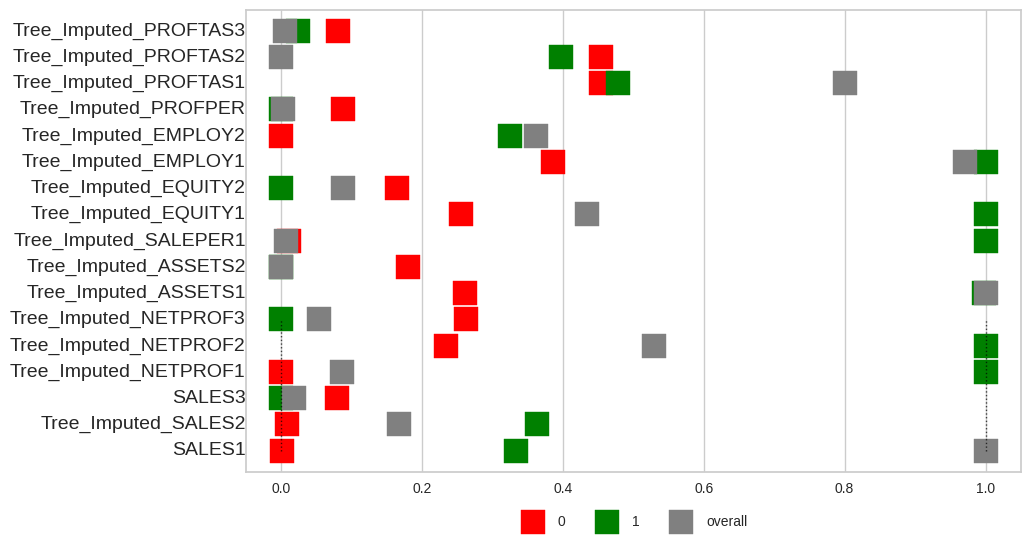

In [71]:
from numpy.ma.core import size
fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.vlines(x=0, ymin=0, ymax=5, color="black", alpha=0.7, linewidth=1, linestyles='dotted')
ax.vlines(x=1, ymin=0, ymax=5, color="black", alpha=0.7, linewidth=1, linestyles='dotted')
y_reversed_index= list(range(len(K_Means_7_Manhattan_plot_table)))
y_reversed_index.reverse()

ax.scatter(x= K_Means_7_Manhattan_plot_table['0_norm'], y= y_reversed_index, marker= 's', s=300, c='red', label='0')
ax.scatter(x= K_Means_7_Manhattan_plot_table['1_norm'], y= y_reversed_index, marker= 's', s=300, c='green', label='1')
ax.scatter(x= K_Means_7_Manhattan_plot_table['overall_norm'], y= y_reversed_index, marker= 's', s=300, c='grey', label='overall')
for i in y_reversed_index:
  ax.text(0-0.05, i, K_Means_7_Manhattan_plot_table.iloc[i][0], horizontalalignment= 'right', verticalalignment='center',
          fontdict={'size':14})
ax.legend(loc='lower center', ncol=10, bbox_to_anchor=(0.5, -0.15))
ax.get_yaxis().set_visible(False)

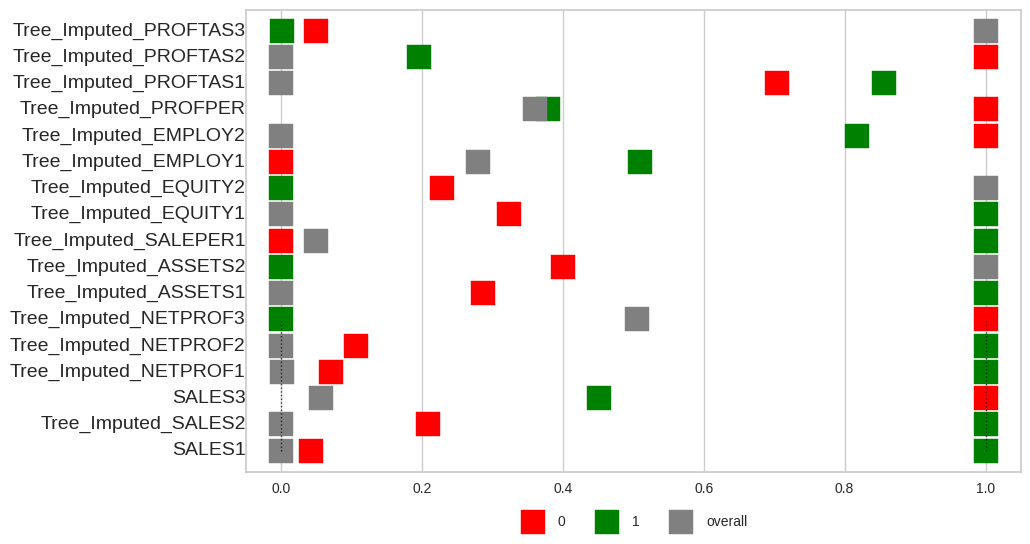

In [72]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.vlines(x=0, ymin=0, ymax=5, color="black", alpha=0.7, linewidth=1, linestyles='dotted')
ax.vlines(x=1, ymin=0, ymax=5, color="black", alpha=0.7, linewidth=1, linestyles='dotted')
y_reversed_index= list(range(len(K_Means_5_Chisqr_plot_table)))
y_reversed_index.reverse()

ax.scatter(x= K_Means_5_Chisqr_plot_table['0_norm'], y= y_reversed_index, marker= 's', s=300, c='red', label='0')
ax.scatter(x= K_Means_5_Chisqr_plot_table['1_norm'], y= y_reversed_index, marker= 's', s=300, c='green', label='1')
ax.scatter(x= K_Means_5_Chisqr_plot_table['overall_norm'], y= y_reversed_index, marker= 's', s=300, c='grey', label='overall')
for i in y_reversed_index:
  ax.text(0-0.05, i, K_Means_5_Chisqr_plot_table.iloc[i][0], horizontalalignment= 'right', verticalalignment='center',
          fontdict={'size':14})
ax.legend(loc='lower center', ncol=10, bbox_to_anchor=(0.5, -0.15))
ax.get_yaxis().set_visible(False)

# FEATURE IMPORTANCE BETWEEN K_Means_5_Chisqr_labels, K_Means_7_Manhattan_labels

We could use tree based models to convert the unsupervised clustering results into supervised classification problem. The classification model can be use to extract feature importance or describe each cluster using explanatory rules.

Using sklearn's ensemble.RandomForestClassifier to extract clustering feature importance.

## K_Means_5_Chisqr_labels Feature Importance

In [73]:
chisqr_5_Kmeans = RandomForestClassifier(random_state=101)
chisqr_5_Kmeans.fit(Tree_impute_df, K_Means_5_Chisqr_labels)

RandomForestClassifier(random_state=101)

In [74]:
chisqr_5_Kmeans_Features = chisqr_5_Kmeans.feature_importances_

chisqr_5_Kmeans_Features_List = []

for i,v in enumerate(chisqr_5_Kmeans_Features):
  chisqr_5_Kmeans_dict= {}
  chisqr_5_Kmeans_dict['Features'] = Tree_impute_df.columns[i]
  chisqr_5_Kmeans_dict['Importance'] = round(v, 3)
  chisqr_5_Kmeans_Features_List.append(chisqr_5_Kmeans_dict)

chisqr_5_Kmeans_DT_table = pd.DataFrame(chisqr_5_Kmeans_Features_List)
chisqr_5_Kmeans_DT_table.sort_values(by= 'Importance', ascending=False)

,Features,Importance
6,Tree_Imputed_ASSETS1,0.151
10,Tree_Imputed_EQUITY2,0.146
7,Tree_Imputed_ASSETS2,0.130
9,Tree_Imputed_EQUITY1,0.125
3,Tree_Imputed_NETPROF1,0.062
5,Tree_Imputed_NETPROF3,0.061
2,SALES3,0.054
12,Tree_Imputed_EMPLOY2,0.054
14,Tree_Imputed_PROFTAS1,0.047
11,Tree_Imputed_EMPLOY1,0.044


## K_Means_7_Manhattan_labels Feature Importance

In [75]:
manhattan_7_Kmeans = RandomForestClassifier(random_state=101)
manhattan_7_Kmeans.fit(Tree_impute_df, K_Means_7_Manhattan_labels)

RandomForestClassifier(random_state=101)

In [76]:
manhattan_7_Kmeans_Features = manhattan_7_Kmeans.feature_importances_

manhattan_7_Kmeans_Features_List = []

for i,v in enumerate(manhattan_7_Kmeans_Features):
  manhattan_7_Kmeans_dict= {}
  manhattan_7_Kmeans_dict['Features'] = Tree_impute_df.columns[i]
  manhattan_7_Kmeans_dict['Importance'] = round(v, 3)
  manhattan_7_Kmeans_Features_List.append(manhattan_7_Kmeans_dict)

manhattan_7_Kmeans_DT_table = pd.DataFrame(manhattan_7_Kmeans_Features_List)
manhattan_7_Kmeans_DT_table.sort_values(by= 'Importance', ascending=False)

,Features,Importance
6,Tree_Imputed_ASSETS1,0.169
10,Tree_Imputed_EQUITY2,0.162
7,Tree_Imputed_ASSETS2,0.141
9,Tree_Imputed_EQUITY1,0.128
11,Tree_Imputed_EMPLOY1,0.062
12,Tree_Imputed_EMPLOY2,0.058
2,SALES3,0.051
3,Tree_Imputed_NETPROF1,0.050
5,Tree_Imputed_NETPROF3,0.045
14,Tree_Imputed_PROFTAS1,0.039


## PIE CHART CLUSTERS FOR EACH LABEL

### K_Means_5_Chisqr pie chart for clusters

In [77]:
K_Means_5_Chisqr_label_df = Tree_impute_df.copy()
K_Means_5_Chisqr_label_df['label'] = K_Means_5_Chisqr_labels

   label  counts  %count
0      0      48     4.8
1      1       9     0.9
2      2      86     8.6
3      3     525    52.5
4      4     332    33.2


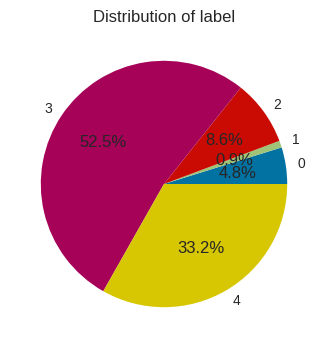

In [78]:
#Tree imputation 5 clusters lloyd outliers
fun.pie_cate(K_Means_5_Chisqr_label_df, 'label')

### K_Means_7_Manhattan pie chart for clusters

In [80]:
K_Means_7_Manhattan_label_df = Tree_impute_df.copy()
K_Means_7_Manhattan_label_df['label'] = K_Means_7_Manhattan_labels

   label  counts  %count
0      0     349    34.9
1      1       1     0.1
2      2       2     0.2
3      3      38     3.8
4      4      37     3.7
5      5     570    57.0
6      6       3     0.3


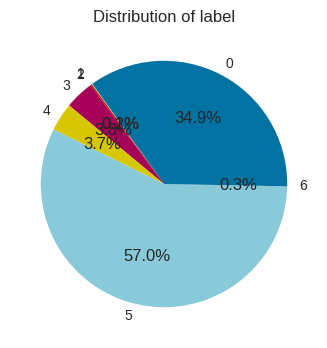

In [81]:
#Tree imputation 7 clusters lloyd outliers
fun.pie_cate(K_Means_7_Manhattan_label_df, 'label')